## Customer Segmentation using K-Means


## Objective
To segment customers based on income and spending behavior using K-Means clustering and identify different customer groups for business insights.

## Data Loading


The dataset is loaded using pandas, and initial rows are displayed to understand the structure and content of the data.

(imports + reading file)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Understanding

This step involves examining the dataset structure, data types, and summary statistics to gain insights into the data distribution and features.

In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Data Cleaning

The dataset is checked for missing or inconsistent values to ensure data quality before performing analysis and modeling.

In [8]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

No missing values found in the dataset.

## Exploratory Data Analysis (EDA)

EDA is performed to analyze patterns and relationships in the data using visualizations such as distributions and scatter plots.

**Age Distribution**

This plot shows the distribution of customers across different age groups to understand the dominant age range.

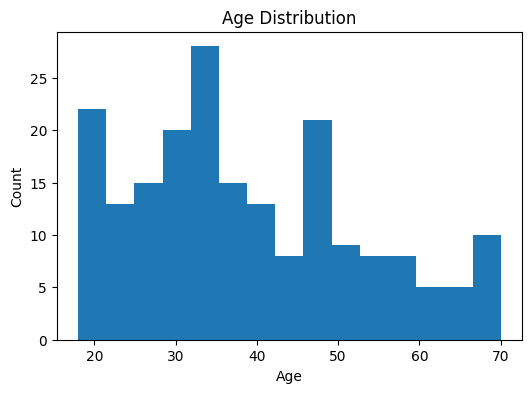

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

**Income Distribution**

This visualization highlights how customer income is distributed, helping identify income segments.

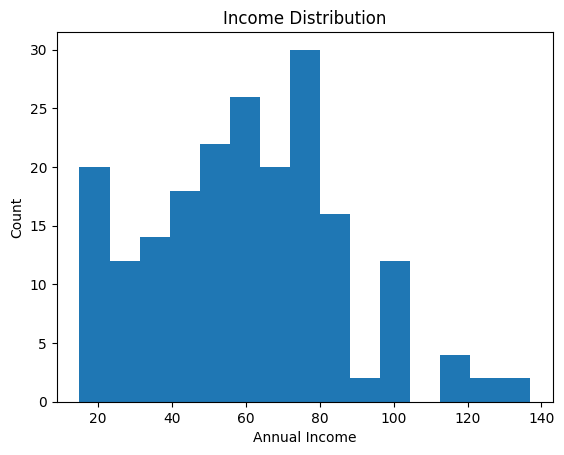

In [10]:
plt.hist(df['Annual Income (k$)'], bins=15)
plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

**Spending Score Distribution**

This plot shows how customers are distributed based on their spending behavior.

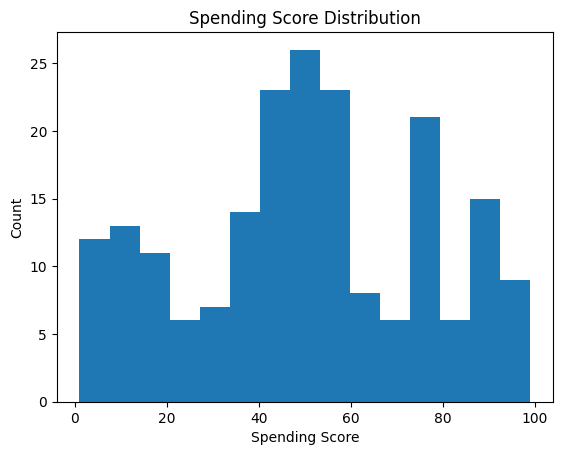

In [11]:
plt.hist(df['Spending Score (1-100)'], bins=15)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.show()

**Income vs Spending**

This scatter plot helps identify relationships between income and spending, which is useful for clustering.

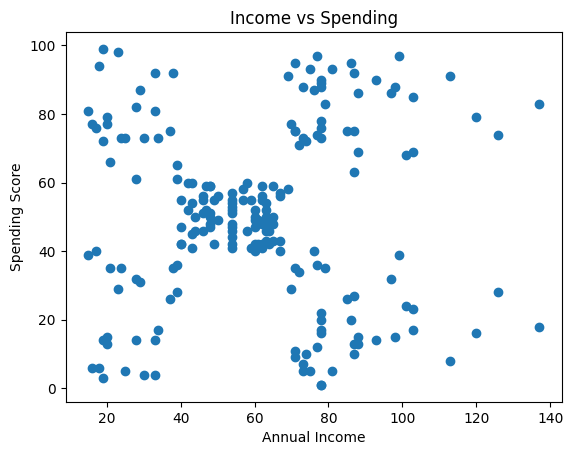

In [12]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.title("Income vs Spending")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

## Feature Selection


Relevant features such as annual income and spending score are selected as inputs for clustering analysis.

In [13]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

## Elbow Method


The elbow method is used to determine the optimal number of clusters by analyzing WCSS values.

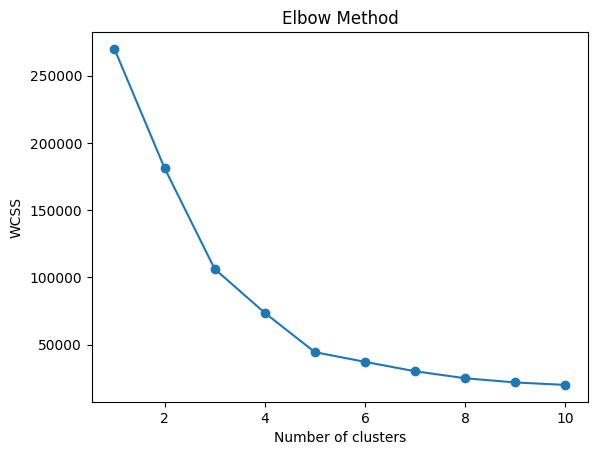

In [14]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

## K-Means Clustering


K-Means clustering is applied to group customers into different segments based on their behavior.

In [15]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

## Cluster Visualization

Clusters are visualized to observe how customers are grouped.

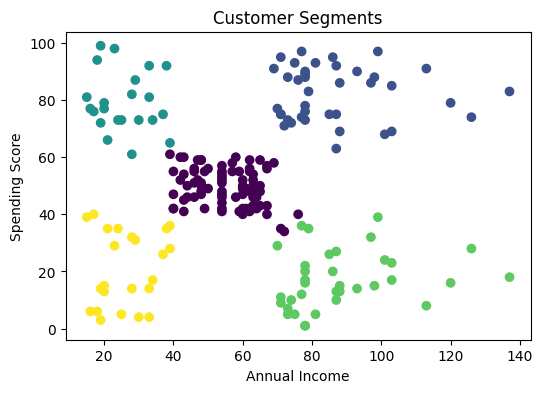

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

## Cluster Analysis

Average values of each cluster are analyzed to understand customer characteristics.

In [17]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean()

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,55.296296,49.518519,42.716049
1,86.538462,82.128205,32.692308
2,25.727273,79.363636,25.272727
3,88.200000,17.114286,41.114286
4,26.304348,20.913043,45.217391


## Business Insights

Insights are derived from clusters to support business decision-making.

- Customers with high income and high spending represent premium customers and should be prioritized.
- Customers with high income but low spending are potential targets for marketing campaigns.
- Customers with low income but high spending may respond well to discounts and offers.
- Low income and low spending customers contribute less to revenue.
- Medium income and spending customers represent stable and regular buyers.

## Conclusion

Customer segmentation helps businesses better understand customer behavior and enables targeted marketing strategies to improve performance.